In [26]:
!pip install --upgrade collatex

In [27]:
pip install python-Levenshtein

Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install grapheme
!pip install pandas
!pip install seaborn
!pip install scipy
!pip install --upgrade numpy

In [1]:
from glob import glob #alle bestandspaden terugvinden die overeenkomen met specifiek patroon
import os #aanmaken van mappen, verwijderen van mappen,...
from itertools import combinations #reeks verzameling cijfers/letters, combinaties in lexicografische volgorde
import grapheme #voor stringmanipulatie & rekenfucties -> stel je hebt x = 'n̄', dan len(x) = 2 (want 2 bytes), grapheme.length(x) is dan wel 1
from collatex import * #alle functies van collatex importeren, * geeft weer dat het om alle functies gaat
from tqdm import tqdm #progress meters toevoegen
import numpy as np #numpy dient om met lijsten/arrays te werken 
import pandas as pd #gebruik maken van de functies van Panda, zoals pd.DataFrame
import seaborn as sb #statistical data visualization
import matplotlib.pyplot as plt #creating static/animated/interactive visualizations

from lxml import etree
from re import sub #re — Regular expression operations #
import xml.etree.ElementTree as ET
import string

In [2]:
#sigles = [os.path.basename(fn).replace('xml_', '').replace('.xml', '') for fn in glob('../../data/xml_martijn/*.xml')] #maak een lijst van sigles, doe dat door de basisnaam van een specifiek path te nemen (fn) en daarin .txt te vervangen, for... in ... = loop
sigles = [os.path.basename(fn).replace('xml_', '').replace('.xml', '') for fn in glob('../../../data/martijnmanuscripts/data/xml/*.xml')]
sigles = sorted(sigles)
sigles

['A',
 'Ant',
 'B',
 'Br',
 'C',
 'D',
 'D2',
 'E',
 'F',
 'G',
 'Ge',
 'K',
 'L',
 'O',
 'W',
 'Y',
 'Z']

In [3]:
#sigles = 'G', 'Z'

#sigles = 'A', 'B'
sigles = 'A','Ant','B', 'BR', 'C','D', 'D2','E', 'F', 'G', 'Ge', 'K', 'L', 'O', 'W', 'Y', 'Z'

In [4]:
def get_gap_lines(tree):
    gap_lines = []
    for text in tree.iterfind('.//' + "{" + NSMAP["MVN"] + "}" + 'text'):
        if 'n' in text.attrib:
            for line in text.iterfind('.//' + "{" + NSMAP["MVN"] + "}" + 'l'):
                if line.find('.//' + "{" + NSMAP["MVN"] + "}" + 'gap') is not None:
                    if 'n' in line.attrib:
                        n_value = line.attrib['n']
                        parts = n_value.split('_')
                        if len(parts) > 1:
                            k = "_".join(parts[1:])  # Join the parts after the first underscore
                        else:
                            k = n_value
                        gap_lines.append(k)

    return gap_lines

In [5]:
NSMAP = {'MVN': 'http://www.tei-c.org/ns/1.0'} #namespace = collectie van 'symbolic names'
removes = ('teiHeader', 'fw', 'supplied', 'abbr') #fw = forme work = headers, footers,...supplied = tekst toegevoegd door de transcriber 
removes_expan_false = ('teiHeader', 'fw', 'supplied', 'ex', 'expan')
chars = {'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l','m', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'}       

In [9]:
import re
def extract_lines(xml_file, expan = True, #def = fuctie maken die alleen wordt uitgevoerd als je die oproept, extract_lines = de naam van de functie, xml_file = argument in de functie, na de functienaam in ()
                  punct = True, lower = True,
                  sep_abbr = True): 
    
    lines = {}
    tree = etree.parse(xml_file) #ElementTree represents the whole XML document as a tree, and Element represents a single node
    
    
    if expan:
        #delete all elements with the provided tag names from a tree or subtree
        #will also remove the tail text unless explicitly set the with_tail keyword argument option to False
        etree.strip_elements(tree, ("{"+ NSMAP["MVN"]+ "}" + s for s in removes), with_tail=False) 
    else: 
        etree.strip_elements(tree, ("{"+ NSMAP["MVN"]+ "}" + s for s in removes_expan_false), with_tail=False)
  
    context = etree.iterwalk(tree, events=("start", "end")) #a tree walker generates events from an existing tree. 'Start' and 'end' represent opening and closing elements
    #u prefix indicates Unicode
    text = u"" #een lege string die tekst heet, u staat voor Unicode 
    #this will be the key in the dictionary of lines {}
    k = '' 
    
    for action, node in context: #bij elke actie bij een element/knooppunt in het overlopen van het xml bestand
        #remove ns for easier access
        #tag_only bevat de tags op een knooppunt
        #.tag selects all child elements with the given tag. A tag is a string identifying what kind of data this element represents (the element type, in other words).
        #.replace removes ns www.tei...
        
        tag_only = node.tag.replace("{http://www.tei-c.org/ns/1.0}","") 
            
        #node.attrib: XML elements have attributes 
        #attrib is a dictionary containing the element’s attributes. 
        if 'n' in node.attrib and tag_only == 'text': 
            title = node.attrib['n'] #for example Eerste Martijn

        if 'n' in node.attrib and tag_only == "l":
           # k = node.attrib['n']
            n_value = node.attrib['n']
            parts = n_value.split('_')
            if len(parts) > 1:
                k = "_".join(parts[1:])  # Join the parts after the first underscore
            else:
                k = n_value 
  
        # if a new pb (standalone element) is processed:
        if action == 'start' and tag_only == 'text': 
            continue
            
        elif action == 'start' and tag_only == 'lg':
            continue 
            
        # if new lb (standalone) is processed:
        elif action == 'start' and tag_only == 'lb':
            continue

        # list elements which you want to iterate through. this is not really neccessary.
        elif tag_only in ("group","text","MVN","body","cb","p","note"):
            continue


        # for all other elements, distinguish bet ween the start-event of the processing and
        # and the end-event. Attach the tail AFTER the child nodes were processed (= end-event) 
         
        elif action == 'start':
            #comment the following two lines out to not get the element markers
            #f.write(f"[{tag_only}]") 
            #text += f"[{tag_only}]"

            ############################################################################
            ########## filter out special characters, bars,                   ##########
            ########## superscript, or specific tags.                         ##########
            ############################################################################
                    
            
            #if a special glyph is present, encode it accordingly
                
            if tag_only == 'g':
                if sep_abbr: #extra toegevoegd door Mike, maar wij gebruiken nu toch de combining macron onder else want mogelijk door 'grapheme'  
                    if node.attrib['ref'] == '#bar': # ā, ē, ī, ō, ū, n̄ etc.
                        text += u'\u005f' #low line _

                    elif node.attrib['ref'] == '#apomod': # ʼ
                        text += u'\u02bc'

                    elif node.attrib['ref'] == '#usmod': # ꝰ
                        text += u'\ua770' 

                    elif node.attrib['ref'] == '#condes': # ꝯ
                        text += u'\ua76f'

                    elif node.attrib['ref'] == '#para': # ¶
                        text += u'\xb6'

                    elif node.attrib['ref'] == '#etfin': # ꝫ
                        text += u'\ua76b'

                    elif node.attrib['ref'] == '#pbardes': # ꝑ
                        text += '\ua751'

                    elif node.attrib['ref'] == '#pbardes': # ꝕ
                        text += u'\ua755'

                    elif node.attrib['ref'] == '#pflour': # ꝓ
                        text += u'\ua753'

                    else:
                        text += str(node.attrib['ref']) # get the actual ref if there still are any left
                    
                else:
                    if node.attrib['ref'] == '#bar': # ā, ē, ī, ō, ū, n̄ etc.
                        text += u'\u0304'

                    elif node.attrib['ref'] == '#apomod': # ʼ
                        text += u'\u02bc'

                    elif node.attrib['ref'] == '#usmod': # ꝰ
                        text += u'\ua770'

                    elif node.attrib['ref'] == '#condes': # ꝯ
                        text += u'\ua76f'

                    elif node.attrib['ref'] == '#para': # ¶
                        text += u'\xb6'

                    elif node.attrib['ref'] == '#etfin': # ꝫ
                        text += u'\ua76b'

                    elif node.attrib['ref'] == '#pbardes': # ꝑ
                        text += u'\ua751'

                    elif node.attrib['ref'] == '#pbardes': # ꝕ
                        text += u'\ua755'

                    elif node.attrib['ref'] == '#pflour': # ꝓ
                        text += u'\ua753'

                    else:
                        node.attrib['ref']
                        text += str(node.attrib['ref']) # get the actual ref if there still are any left

            # encode superscript letters
            superscript_dict = {'a':'ᵃ', 'b':'ᵇ', 'c':'ᶜ', 'd':'ᵈ', 'e':'ᵉ', 'f':'ᶠ',
                               'g':'ᵍ', 'h':'ʰ', 'i':'ᶦ', 'j':'ʲ', 'k':'ᵏ', 'l':'ˡ', 
                                'm':'ᵐ', 'n':'ⁿ', 'o':'ᵒ', 'p':'ᵖ', 'r':'ʳ', 's':'ˢ', 
                                't':'ᵗ', 'u':'ᵘ', 'v':'ᵛ', 'w':'ʷ', 'x':'ˣ', 'y': 'ʸ', 'z': 'ᶻ'}

            if tag_only == 'hi' and 'rend' in node.attrib and node.attrib['rend'] == 'superscript': #rend(ition) supplies information about the appearance of an element
                if node.text in superscript_dict:
                    text += str(superscript_dict[node.text]).strip()

            #elif tag_only == 'ex':
                  #  text += str('*'+node.text+'€')

            # encode punctuation marks
            elif tag_only == 'pc':
                text += str(node.text).strip()

            # encode roman numerals
            elif tag_only == 'num':
                if node.text:
                    text += str('.'+node.text+'.').strip()

            # if there is still a node with text in it
            elif (node.text):
                text += node.text        

        # after the child elements
        elif action == 'end':
            #if there is a tail
            #the tail attribute holds the text between the element’s end tag and the next tag, or None
            if (node.tail and node.tail not in "\t"): #if the tail is not yet in the text 
                #comment the following two lines out to not get the tail marker
                #text += "[tail]"
                #f.write("[tail]")
                #append to text-concatenation
                text += str(node.tail)

        if tag_only == 'l' or tag_only == 'lg':
            if k: 
                text = sub(r'\n', '', text) 
                
        if tag_only == 'lb':
            if k:
                text = sub(r'\n', '', text) #when an "r" prefix is present, a character following a backslash is included in the string/all backslashes are left in string. 
                if not punct:
                    punctuation_with_pilcrow = string.punctuation + '¶' + '⸫'
                    text = text.translate(str.maketrans('', '', punctuation_with_pilcrow))
                    #text = re.sub(r'\s+', ' ', text).strip()
                    text = text.translate(str.maketrans('', '', string.punctuation)) #the value of the keys k is the text 
                if lower: 
                    text = text.lower()
                   
                    #text = text[::-1]
                  
                lines[k] = text #the value of the keys k is the text 
                
                text = ''
    
        
                
    # catch dangling last line (if applicable):
    if text:
        lines[k] = text
    text = sub(r'\n', '', text)  # Verwijder nieuwe regels

    if not punct:
        punctuation_with_pilcrow = string.punctuation + '¶' + '⸫'
        text = text.translate(str.maketrans('', '', punctuation_with_pilcrow))
        text = re.sub(r'\s+', ' ', text).strip()
        #text = text.translate(str.maketrans('', '', string.punctuation))  # Verwijder interpunctie
    if lower:
        text = text.lower()  # Zet om naar kleine letters
    lines[k] = text 
    
    num_orig_lines = len(lines)
    print(num_orig_lines)
    # remove lines with gaps:
    #gap_lines = get_gap_lines(tree)
    #lines = {k:v for k, v in lines.items() if k not in gap_lines}
    print(f'-> removed {num_orig_lines - len(lines)} lines with gaps')
    #lines = {k:v for k, v in lines.items() if v.strip()} #if a line with a gap is removed, remove empty key, strip() removes spaces #The items() method returns a key-value pair

    
    return lines
    #num_orig_lines = len(lines)
    #print(num_orig_lines)
d = extract_lines(f'../../../data/martijnmanuscripts/data/xml/xml_{sigles[10]}.xml', expan = True, punct = True, lower = True)
#print(d)

148
-> removed 0 lines with gaps


In [10]:
mss = {} #dictionary maken van manuscripten


for sigle in tqdm(sigles):
    mss[sigle] = extract_lines(f'../../../data/martijnmanuscripts/data/xml/xml_{sigle}.xml', #for... in = loop, toont progress meter 
   # mss[sigle] = extract_lines(f'../../data/xml_martijn/xml_{sigle}.xml',
                               expan = True, punct = False, lower = True,
                               sep_abbr = False) #f string waarin 'sigle' wordt ingevuld
print(mss['A'])

 53%|████████████████████████████████████████▏                                   | 9/17 [00:00<00:00, 35.66it/s]

1767
-> removed 0 lines with gaps
104
-> removed 0 lines with gaps
1816
-> removed 0 lines with gaps
604
-> removed 0 lines with gaps
1472
-> removed 0 lines with gaps
1811
-> removed 0 lines with gaps
247
-> removed 0 lines with gaps
276
-> removed 0 lines with gaps
1821
-> removed 0 lines with gaps


100%|███████████████████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 37.84it/s]

1770
-> removed 0 lines with gaps
148
-> removed 0 lines with gaps
67
-> removed 0 lines with gaps
700
-> removed 0 lines with gaps
1821
-> removed 0 lines with gaps
508
-> removed 0 lines with gaps
348
-> removed 0 lines with gaps
534
-> removed 0 lines with gaps
{'M1_01_001': 'vvaphene martin hoe salt gaen', 'M1_01_002': 'sal die weerelt hiet langhe staen', 'M1_01_003': 'in dus crancken loue', 'M1_01_004': 'so moet vrouwe vereere saen', 'M1_01_005': 'sonder twifel ende waen', 'M1_01_006': 'rumen heeren houe', 'M1_01_007': 'ic zie den valschen wel ontfaen', 'M1_01_008': 'die de heeren conen dwaen', 'M1_01_009': 'ende plucken vanden stoue', 'M1_01_010': 'ende ic zie den rechten slaen', 'M1_01_011': 'beede bespotten ende beuaen', 'M1_01_012': 'alse die meese in de cloue', 'M1_01_013': 'rechts offene god verscroue', 'M1_02_014': 'hoe langhe sal ghedoghen dit', 'M1_02_015': 'god die alle dinc besit', 'M1_02_016': 'in sine heerscapie', 'M1_02_017': 'dat die goede vleeuwet ende bit', 'M1_02

In [135]:
print(mss.keys()) #print de keys van de dictionary mss

dict_keys(['A', 'Ant', 'B', 'BR', 'C', 'D', 'D2', 'E', 'F', 'G', 'Ge', 'K', 'L', 'O', 'W', 'Y', 'Z'])


In [136]:
mss.keys()

dict_keys(['A', 'Ant', 'B', 'BR', 'C', 'D', 'D2', 'E', 'F', 'G', 'Ge', 'K', 'L', 'O', 'W', 'Y', 'Z'])

In [137]:
import re
idx = set()
for ms in mss:
    idx.update(set(mss[ms].keys()))
idx = sorted(idx)
witnesses = sorted(mss.keys())

lines = np.empty([len(idx), len(witnesses)], dtype="object")

for ms in mss.keys():
    for l in mss[ms]:
        lines[idx.index(l), witnesses.index(ms)] = mss[ms][l].replace('*', '<i>').replace('€', '</i>')

lines = pd.DataFrame(lines, index=idx, columns=witnesses)
lines.to_excel('synoptic.xlsx')
lines.to_html('synoptic.html', escape=False)

In [138]:
# from: https://gist.github.com/slowkow/06c6dba9180d013dfd82bec217d22eb5

def align_nw(x, y, match = 1, mismatch = 1, gap = 1): #nw needleman-wunsch,  'def' = functie header/functienaam = unieke naam voor functie waarmee deze aangeroepen kan worden.Tussen haakjes zet je parameters.
    x = list(grapheme.graphemes(x)) #body van de functie. functie voert specifieke taak uit en  argumenten die zijn ingegeven w omgezet in een output
    y = list(grapheme.graphemes(y)) #door met .grapheme te werken telt het n̄ als 1 en niet als 2 
    
    
    nx = len(x) # length of first sequence 
    #print(nx)
    ny = len(y) # length of second sequence
    #print(ny)
    
    # Optimal score at each possible pair of characters.
    # Initialization process - forming the base matrix
    F = np.zeros((nx + 1, ny + 1)) #Return an array/reeks van de lengte van x en y, telkens +1, filled with zeros.
    F[:,0] = np.linspace(0, -nx, nx + 1) #[first_row:last_row , column_0] #de eerste rij en laatste rij van de eerste kolom (van 0 tot -22, met interval van 23)
    F[0,:] = np.linspace(0, -ny, ny + 1) #de eerste kolom, eerste en laatste getal van de rij, np.linspace = Return evenly spaced numbers over a specified interval.
    #print (F)
    
    # Pointers to trace through an optimal aligment. Aanknopingspunten om een optimale alignering te traceren. Initialize a pointer matrix P
    P = np.zeros((nx + 1, ny + 1)) #weer een reeks van de lengte van x en y, telkens +1, gevuld met nullen
    P[:,0] = 3 #eerste kolom = 3
    P[0,:] = 4 #eerste rij = 4
    #print(P)
    
    
    # Temporary scores.
    t = np.zeros(3) #[0.0.0.] t is a three-element matrix that stores three values: Match or mutation between the first and second sequence (what would be the score representation → trying to find the least); Inserting a gap inside of the first sequence (addition); Inserting a gap inside of the second sequence (deletion)
    for i in range(nx): #loop over de range die gaat van 0 tot 21
        for j in range(ny): #loop over de range die gaat van 0 tot 22 
            if x[i] == y[j]: # Iteration step: take the max (inserting gap in first sequence, inserting gap in second sequence, match or mutation)       
                t[0] = F[i,j] + match
            else:
                t[0] = F[i,j] - mismatch
            t[1] = F[i,j+1] - gap
            t[2] = F[i+1,j] - gap
            tmax = np.max(t) #neemt het maximum van de rijen
            F[i+1,j+1] = tmax
            if t[0] == tmax:
                P[i+1,j+1] += 2
            if t[1] == tmax:
                P[i+1,j+1] += 3
            if t[2] == tmax:
                P[i+1,j+1] += 4
    # Trace through an optimal alignment.
    i = nx
    j = ny
    rx = []
    ry = []
    while i > 0 or j > 0:
        if P[i,j] in [2, 5, 6, 9]:
            rx.append(x[i-1])
            ry.append(y[j-1])
            i -= 1
            j -= 1
        elif P[i,j] in [3, 5, 7, 9]:
            rx.append(x[i-1])
            ry.append('-')
            i -= 1
        elif P[i,j] in [4, 6, 7, 9]:
            rx.append('-')
            ry.append(y[j-1])
            j -= 1
    # Reverse the strings.
    rx = rx[::-1]
    ry = ry[::-1]
    return rx, ry #Met een return statement geeft je een output waarde uit een functie.

a, b = align_nw('en̄ niet sceldē dē heʼe', 'en̄ niet scelden dē here')
#a, b = align_nw('sal dese werelt yet lānge staē', 'Sal dese weerelt yet langhe staen')
#a, b = align_nw('hi storttte dor ons hallo', 'hi storte dor ons')
print(a)
print(b)

['e', 'n̄', ' ', 'n', 'i', 'e', 't', ' ', 's', 'c', 'e', 'l', 'd', '-', 'ē', ' ', 'd', 'ē', ' ', 'h', 'e', 'ʼ', 'e']
['e', 'n̄', ' ', 'n', 'i', 'e', 't', ' ', 's', 'c', 'e', 'l', 'd', 'e', 'n', ' ', 'd', 'ē', ' ', 'h', 'e', 'r', 'e']


In [139]:
def align_collatex(l1, l2):
    A = [{'t': c, 'n': c} for c in grapheme.graphemes(l1)] #t staat voor diplomatisch (text), n staat voor normalized, loop over al de characters 
    
    B = [{'t': c, 'n': c} for c in grapheme.graphemes(l2)]
    json_form = {'witnesses': [{'id': 'A', 'tokens': A}, #witnesses is het root element, hierin zitten de te vergelijken versies, elke versie heeft een unieke id
                               {'id': 'B', 'tokens': B}],
                } #de inhoud zijn de tokens, hierboven gedefinieerd 

    A, B = str(collate(json_form, 
                       output='table', 
                       segmentation=True, 
                       near_match=False)
              ).split('\n')[1:3] #split() splits a string into a list

    A = A.replace('| A | ', '').replace(' | ', '').replace(' |', '') #haal de | en sigles weg
    B = B.replace('| B | ', '').replace(' | ', '').replace(' |', '')
    
   
    A = list(grapheme.graphemes(A))
    B = list(grapheme.graphemes(B))
    
    return A, B

a, b = align_collatex('en̄ niet sceldē dē heʼe', 'en̄ niet scelden dē here')
#a, b = align_collatex('sal dese werelt yet lānge staē', 'Sal dese weerelt yet langhe staen')
#a, b = align_nw('hi stoertte dor ons', 'hi storte dor ons')
print(a)
print(b)

['e', 'n̄', ' ', 'n', 'i', 'e', 't', ' ', 's', 'c', 'e', 'l', 'd', 'ē', ' ', ' ', 'd', 'ē', ' ', 'h', 'e', 'ʼ', 'e']
['e', 'n̄', ' ', 'n', 'i', 'e', 't', ' ', 's', 'c', 'e', 'l', 'd', 'e', 'n', ' ', 'd', 'ē', ' ', 'h', 'e', 'r', 'e']


In [140]:
def get_distances(mss, method='NW'): #needleman-wunsch
    distances = [] #een lijst maken 
    
    for ms1, ms2 in tqdm(list(combinations(mss.keys(), 2))):# combinations('ABCD', 2) --> AB AC AD BC BD CD #eerste element van combinatie w opgeslagen in ms1 en tweede waarmee je vergelijkt in ms2         
        common_idxs = set(mss[ms1].keys()).intersection(set(mss[ms2].keys()))
        #een set maken, items in a set are unordered #The intersection() method returns a set that contains the similarity between two or more sets, 
        #for loop doet eerst AB BA..., dan zorgt intersection er voor dat AB gebeurt maar niet BA ook nog eens 
        for idx in common_idxs: #A, Ant,... 
            line1, line2 = mss[ms1][idx], mss[ms2][idx] #zoekt binnen dictionary naar de sigle (value 1), en geeft dan de eerste regel tekst (value 2) 
            if method == 'NW': #compare two methods: nw and collatex 
                rx, ry = align_nw(line1, line2) #verwijs naar bovenstaande functies 
            elif method == 'CollateX':
                rx, ry = align_collatex(line1, line2)
            if len(rx) != len(ry): #is niet gelijk aan, dan wordt line 1 en line 2 geprint
                print(line1, line2)
            length = len(rx)
            text = "Martijntrilogy"
            id_ms = idx
            parts = idx.split('_')
            text_part = parts[0]  # e.g., 'M2'
            stanza = int(parts[1])  # e.g., 24
            verse = int(parts[2])
            if text_part == 'M1':
                position_verse = int(verse) / 977  #include title and end words
            elif text_part == 'M2':
                position_verse = int(verse) / 340  
            elif text_part == 'M3':
                position_verse = int(verse) / 509 
            for idx, (a, b) in enumerate(zip(rx, ry)): #You get the index with enumerate(), and get the elements of multiple iterables with zip().
                if a != b:
                    distances.append((ms1, ms2, text, id_ms, text_part, stanza, verse, position_verse, idx/length, 1, a, b, line1, line2))
                else:
                    distances.append((ms1, ms2, text, id_ms, text_part, stanza, verse, position_verse, idx/length, 0, a, b, line1, line2))

    return pd.DataFrame(distances, columns=('ms1', 'ms2', 'text', 'id_ms', 'text_part', 'stanza', 'verse','position_verse', 'relative position', 'mismatch', 'char1', 'char2', 'line1', 'line2'))


In [141]:
nw_mismatches = get_distances(mss, method='NW') 
cx_mismatches = get_distances(mss, method='CollateX')
nw_mismatches.sample(5) #.sample returns a list with a randomly selection of a specified number of items from a sequence
cx_mismatches.sample(5)
#print(nw_mismatches)
cx_mismatches.to_csv('matches.csv', header=True, index=False)

100%|███████████████████████████████████████████████| 136/136 [04:54<00:00,  2.17s/it]


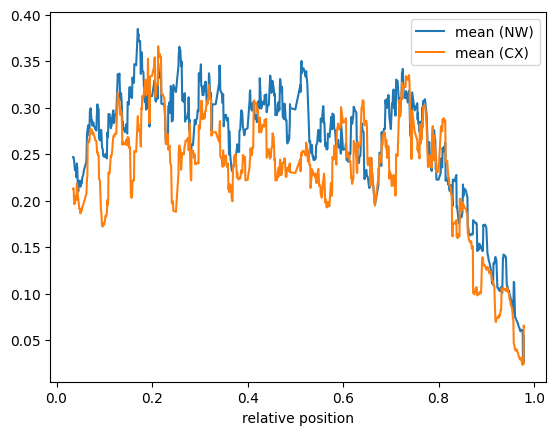

In [142]:
nw_rolling_window = nw_mismatches.groupby('relative position')['mismatch'].mean().rolling(window=20).mean() # groupby() function is used to split the data into groups based on some criteria. 
cx_rolling_window = cx_mismatches.groupby('relative position')['mismatch'].mean().rolling(window=20).mean() #gemiddelde nemen

ax = nw_rolling_window.plot(label="mean (NW)")
cx_rolling_window.plot(label="mean (CX)", ax=ax)

plt.legend() #met afkortingen gaat het op het einde omhoog, zonder daalt het 
plt.savefig('figure15.png', dpi=300)

In [32]:
#checken of de resultaten statistisch significant zijn en dat is zo!
mismatches_end = mismatches[mismatches['position'] > .75]
mismatches_beginning = mismatches[mismatches['position'] <= .75]
from scipy.stats import mannwhitneyu
mannwhitneyu(mismatches_end['mismatch'], mismatches_beginning['mismatch'], alternative='less')

NameError: name 'mismatches' is not defined

0.28316157037029205
0.2633341911328702


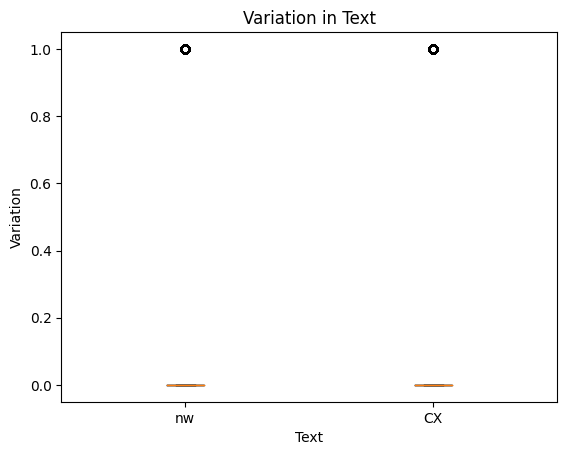

In [33]:
plt.boxplot([nw_mismatches['mismatch'],cx_mismatches['mismatch']], labels=['nw','CX'])
#plt.axhline(y=cx_mean_mismatch, color='r', linestyle='--', label="Overall mean (NW)")
#plt.axhline(y=nw_mean_mismatch, color='g', linestyle='--', label="Overall mean (CX)")
#print(cx_mean_mismatch)
#print(nw_mean_mismatch)
#plt.legend()
#print(nw_mismatches['mismatch'].mean())
#print(cx_mismatches['mismatch'].mean())
print(nw_rolling_window.mean())
print(cx_rolling_window.mean())
plt.xlabel('Text')
plt.ylabel('Variation')
plt.title('Variation in Text')

plt.savefig('boxplot_figure.png', dpi=300)
plt.show()

In [ ]:
print(nw_rolling_window.mean())
print(cx_rolling_window.mean())
plt.boxplot([nw_rolling_window.mean(),cx_rolling_window.mean()])
plt.axhline(y=nw_rolling_window.mean(), color='r', linestyle='--', label="Overall mean (NW)")
plt.axhline(y=cx_rolling_window.mean(), color='g', linestyle='--', label="Overall mean (CX)")

#plt.legend()
#plt.xlabel('Text')
#plt.ylabel('Variation')
plt.title('Variation in Text')

plt.savefig('boxplot_figure.png', dpi=300)
plt.show()

## Clustermap

In [29]:
for ms in mss:
    print(ms, len(mss[ms]))


  
total_sum = 0
total_words = 0
for ms in mss: 
    total_sum += len(mss[ms]) 
    for k, v in mss[ms].items():
        words = v.split()
        total_words += len(words)

print(total_sum)
print(total_words)

A 1767
Ant 104
B 1816
BR 604
C 1472
D 1811
D2 247
E 276
F 1821
G 1770
Ge 148
K 67
L 700
O 1821
W 508
Y 348
Z 534
15814
79337


In [30]:
# Loop through each manuscript and print the number of entries and the total words in each manuscript
for ms in mss:
    total_words_in_ms = 0  # Initialize word count for the current manuscript
    for k, v in mss[ms].items():
        words = v.split()
        total_words_in_ms += len(words)  # Sum the words for the current entry
    print(ms, len(mss[ms]), total_words_in_ms)  # Print the manuscript, number of entries, and total words

# Calculate the total entries and total words across all manuscripts
total_sum = 0
total_words = 0
for ms in mss:
    total_sum += len(mss[ms])
    for k, v in mss[ms].items():
        words = v.split()
        total_words += len(words)

print(total_sum)  # Total number of entries across all manuscripts
print(total_words)  # Total number of words across all manuscripts


A 1767 8939
Ant 104 117
B 1816 9287
BR 604 2911
C 1472 7471
D 1811 9250
D2 247 1179
E 276 1378
F 1821 9155
G 1770 9120
Ge 148 666
K 67 334
L 700 3224
O 1821 9422
W 508 2663
Y 348 1633
Z 534 2588
15814
79337


In [30]:
sigles = sorted(mss.keys())
print(sigles)
sigles = [s for s in sigles if len(mss[s]) >= 536]
print(sigles)

['A', 'Ant', 'B', 'BR', 'C', 'D', 'D2', 'E', 'F', 'G', 'Ge', 'K', 'L', 'O', 'W', 'Y', 'Z']
['A', 'B', 'BR', 'C', 'D', 'F', 'G', 'L', 'O']


In [31]:
df_clust = np.zeros((len(sigles), len(sigles)))  #Return an array/reeks van de lengte van x en y, gevuld met nullen.
print(df_clust.shape) #The shape property is usually used to get the current shape of an array

(9, 9)


In [32]:
for s1, s2 in combinations(sigles, 2):
    print(s1, s2)
    d = nw_mismatches[(nw_mismatches['ms1'] == s1) & (nw_mismatches['ms2'] == s2)]['mismatch'].mean()
    df_clust[sigles.index(s1), sigles.index(s2)] = d #Python index() = function which searches for a given element from the start of the list and returns the index of the first occurrence. 
    df_clust[sigles.index(s2), sigles.index(s1)] = d

A B
A BR
A C
A D
A F
A G
A L
A O
B BR
B C
B D
B F
B G
B L
B O
BR C
BR D
BR F
BR G
BR L
BR O
C D
C F
C G
C L
C O
D F
D G
D L
D O
F G
F L
F O
G L
G O
L O


In [33]:
df_clust = pd.DataFrame(df_clust, columns=sigles, index=sigles)
df_clust

,A,B,BR,C,D,F,G,L,O
A,0.000000,0.138334,0.151255,0.150137,0.170654,0.154222,0.159977,0.156372,0.163679
B,0.138334,0.000000,0.171492,0.156353,0.167307,0.166084,0.174357,0.177964,0.168833
BR,0.151255,0.171492,0.000000,0.165341,0.145170,0.092204,0.137328,0.125860,0.174868
C,0.150137,0.156353,0.165341,0.000000,0.171893,0.167092,0.174924,0.178372,0.173423
D,0.170654,0.167307,0.145170,0.171893,0.000000,0.141702,0.176830,0.155973,0.174739
F,0.154222,0.166084,0.092204,0.167092,0.141702,0.000000,0.154055,0.131058,0.163057
G,0.159977,0.174357,0.137328,0.174924,0.176830,0.154055,0.000000,0.148271,0.180988
L,0.156372,0.177964,0.125860,0.178372,0.155973,0.131058,0.148271,0.000000,0.176529
O,0.163679,0.168833,0.174868,0.173423,0.174739,0.163057,0.180988,0.176529,0.000000


/Users/sofiemoors/miniconda3/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Users/sofiemoors/miniconda3/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


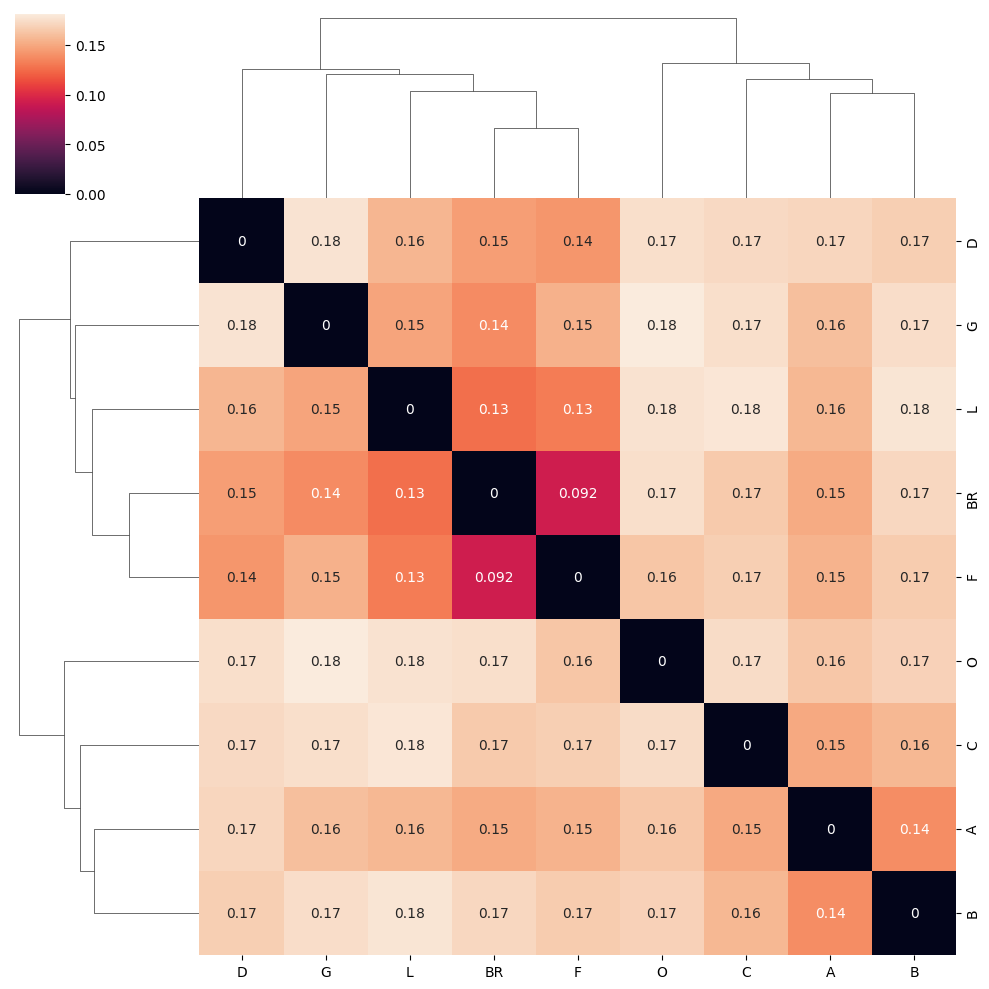

In [34]:
import seaborn as sb
sb = sb.clustermap(df_clust, method='ward', annot=True);
plt.savefig('clustermap.png')

## Abbreviation density

In [35]:
abbr_density = [] #empty list 
sigles = 'A','Ant','B', 'BR', 'C','D', 'D2','E', 'F', 'G', 'Ge', 'K', 'L', 'O', 'W', 'Y', 'Z' #tuple
for sigle in sigles: #loop
    abbr = extract_lines(f'../../data/xml_martijn/xml_{sigle}.xml', expan = False, punct = False, lower = True)
    expan = extract_lines(f'../../data/xml_martijn/xml_{sigle}.xml', expan = True, punct = False, lower = True)
    
    line_idxs = sorted(abbr.keys()) #creates list line_idxs containing sorted keys (line indices) from abbr dictionary
    #print(line_idxs)
    abbr_lens = np.array([len(abbr[line]) for line in line_idxs]) #lengte berekenen afgekort en opslaan als array
    expan_lens = np.array([len(expan[line]) for line in line_idxs]) #lengte berekenen voluit
    
    diffs = pd.Series(expan_lens - abbr_lens) #pd.series = one-dimensional labeled array 
    ratios = pd.Series(abbr_lens / expan_lens)
    abbr_density.append((sigle, diffs.mean(), diffs.std(), ratios.mean(), ratios.std())) #toevoegen aan de lijst, std Standard deviation

dens = pd.DataFrame(abbr_density, columns=['sigle', 'diff-mean', 'diff-std', 'ratio-mean', 'ratio-std']) #dataframe maken van de lijst
dens.dropna(inplace=True) #if you set inplace to True; function will modify original DataFrame directly by dropping missing values, it won't return new DataFrame
dens.set_index('sigle', inplace=True)  #It is used to set one or more columns of a DataFrame as the index, by setting inplace=True, modification is performed on  original df

1766
-> removed 5 lines with gaps
1766
-> removed 5 lines with gaps
104
-> removed 104 lines with gaps
104
-> removed 104 lines with gaps
1816
-> removed 0 lines with gaps
1816
-> removed 0 lines with gaps
604
-> removed 20 lines with gaps
604
-> removed 20 lines with gaps
1472
-> removed 0 lines with gaps
1472
-> removed 0 lines with gaps
1811
-> removed 0 lines with gaps
1811
-> removed 0 lines with gaps
247
-> removed 100 lines with gaps
247
-> removed 100 lines with gaps
276
-> removed 0 lines with gaps
276
-> removed 0 lines with gaps
1821
-> removed 0 lines with gaps
1821
-> removed 0 lines with gaps
1769
-> removed 0 lines with gaps
1769
-> removed 0 lines with gaps
148
-> removed 70 lines with gaps
148
-> removed 70 lines with gaps
67
-> removed 0 lines with gaps
67
-> removed 0 lines with gaps
700
-> removed 162 lines with gaps
700
-> removed 162 lines with gaps
1821
-> removed 0 lines with gaps
1821
-> removed 0 lines with gaps
507
-> removed 0 lines with gaps
507
-> removed 

In [36]:
dens

,diff-mean,diff-std,ratio-mean,ratio-std
sigle,,,,
A,1.281658,1.267670,0.954300,0.043617
B,1.117841,1.179901,0.959656,0.041219
BR,1.220890,1.149618,0.954732,0.040946
C,0.402853,0.824550,0.985194,0.030851
D,0.139150,0.517609,0.995694,0.015843
D2,0.551020,0.820822,0.979643,0.030244
E,2.547101,1.504403,0.906036,0.049708
F,0.600769,0.958123,0.979700,0.031956
G,3.009045,1.686360,0.888833,0.059005


In [37]:
#print(len(dens.index))
#print(dens['diff-mean'])
#print(dens['diff-std'])

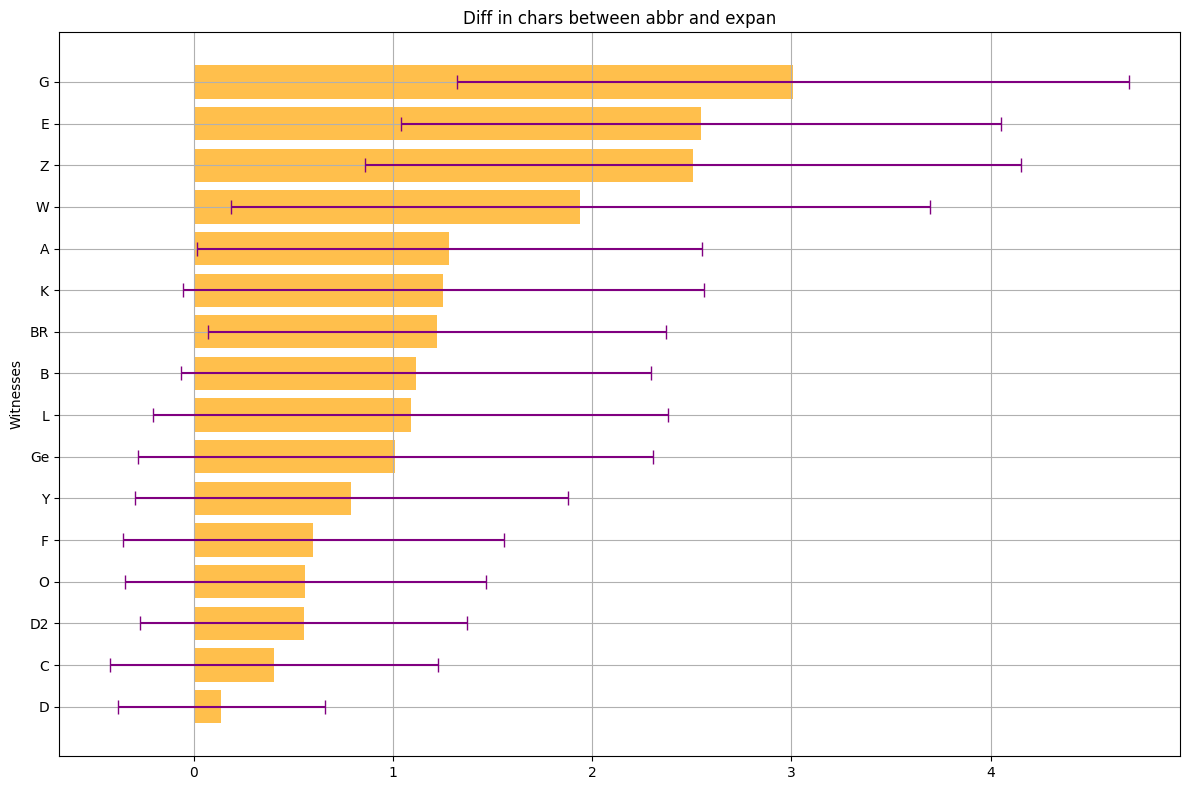

In [38]:
dens.sort_values(by='diff-mean', inplace=True) #by specifies column by which you want to sort data
fig, ax = plt.subplots(figsize=(12, 8)) #plt.subplots() function returns a tuple consisting of fig and an array or list of axes objects (ax
ax.barh(range(len(dens.index)), dens['diff-mean'], #ax.barh() method is used to create a horizontal bar plot, y as: len = 16 (sigles); x-as: gemiddelde 
       xerr=dens['diff-std'], #paarse lijn is de standaarddeviatie; parameter specifies the error or uncertainty in the x-direction for each bar
       color='orange',
       align='center',
       alpha=0.7,
       ecolor='purple', #color of error bars 
       capsize=5)
ax.set_ylabel('Witnesses')
ax.set_yticks(range(len(dens.index)))
ax.set_yticklabels(dens.index)
ax.set_title('Diff in chars between abbr and expan')
ax.xaxis.grid(True) #xaxis.grid(True): It is a method of the axes object (ax) that is used to enable gridlines on the x-axis.
ax.yaxis.grid(True)
plt.tight_layout()
plt.savefig('diffincharsbetweenabbrandexpan.png')

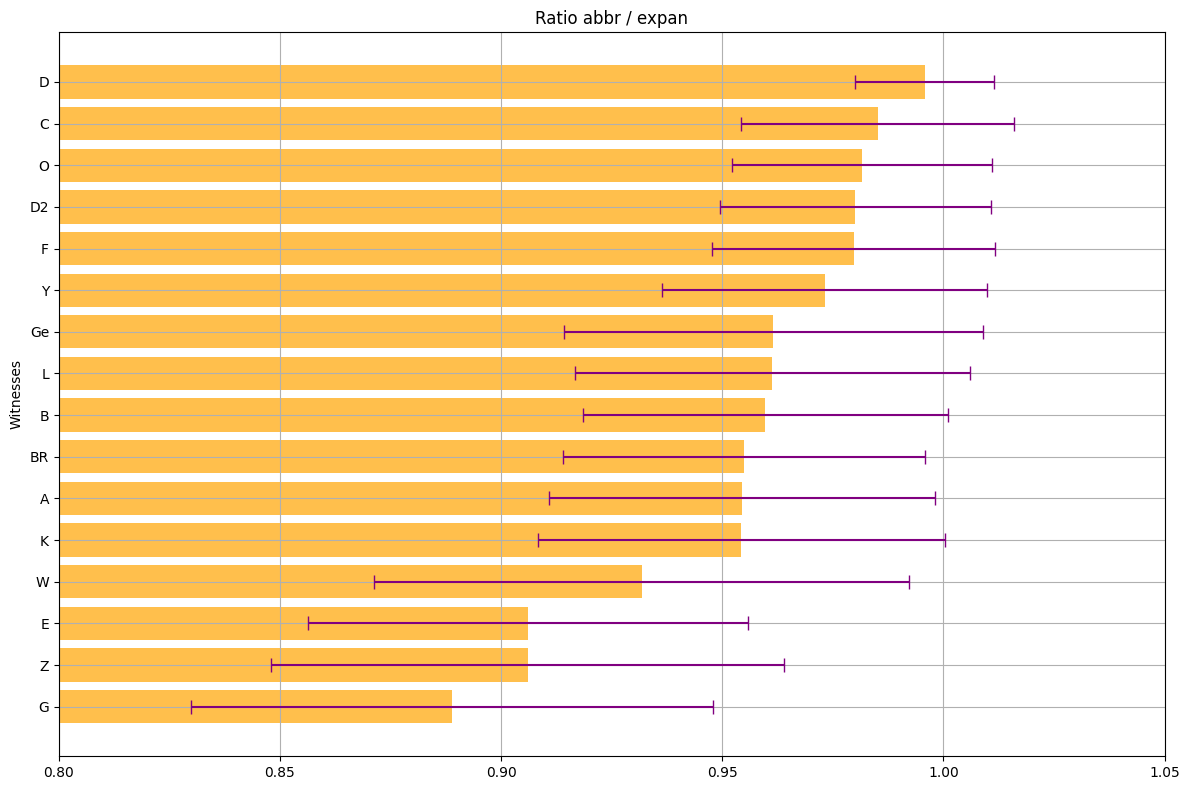

In [95]:
dens.sort_values(by='ratio-mean', inplace=True)
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(dens.index)), dens['ratio-mean'],
       xerr=dens['ratio-std'],
       color='orange',
       align='center',
       alpha=0.7,
       ecolor='purple',
       capsize=5)
ax.set_ylabel('Witnesses')
ax.set_yticks(range(len(dens.index)))
ax.set_yticklabels(dens.index)
ax.set_title('Ratio abbr / expan')
plt.xlim(0.8, 1.05)
ax.xaxis.grid(True)
ax.yaxis.grid(True)
plt.tight_layout()
plt.savefig('ratioabbr_expan.png')


## Pixelplot

In [377]:
import re
def extract_gap_lines(xml_file, expan = True, #def = fuctie maken die alleen wordt uitgevoerd als je die oproept, extract_lines = de naam van de functie, xml_file = argument in de functie, na de functienaam in ()
                  punct = True, lower = True,
                  sep_abbr = True): 
    
    lines = {}
    gap_lines = [] 
    tree = etree.parse(xml_file) #ElementTree represents the whole XML document as a tree, and Element represents a single node
    
    
    if expan:
        #delete all elements with the provided tag names from a tree or subtree
        #will also remove the tail text unless explicitly set the with_tail keyword argument option to False
        etree.strip_elements(tree, ("{"+ NSMAP["MVN"]+ "}" + s for s in removes), with_tail=False) 
    else: 
        etree.strip_elements(tree, ("{"+ NSMAP["MVN"]+ "}" + s for s in removes_expan_false), with_tail=False)
  
    context = etree.iterwalk(tree, events=("start", "end")) #a tree walker generates events from an existing tree. 'Start' and 'end' represent opening and closing elements
    #u prefix indicates Unicode
    text = u"" #een lege string die tekst heet, u staat voor Unicode 
    #this will be the key in the dictionary of lines {}
    k = '' 
    
    for action, node in context: #bij elke actie bij een element/knooppunt in het overlopen van het xml bestand
        #remove ns for easier access
        #tag_only bevat de tags op een knooppunt
        #.tag selects all child elements with the given tag. A tag is a string identifying what kind of data this element represents (the element type, in other words).
        #.replace removes ns www.tei...
        
        tag_only = node.tag.replace("{http://www.tei-c.org/ns/1.0}","") 
            
        #node.attrib: XML elements have attributes 
        #attrib is a dictionary containing the element’s attributes. 
        if 'n' in node.attrib and tag_only == 'text': 
            title = node.attrib['n'] #for example Eerste Martijn

        if 'n' in node.attrib and tag_only == "l":
           # k = node.attrib['n']
            n_value = node.attrib['n']
            parts = n_value.split('_')
            if len(parts) > 1:
                k = "_".join(parts[1:])  # Join the parts after the first underscore
            else:
                k = n_value 
  
        # if a new pb (standalone element) is processed:
        if action == 'start' and tag_only == 'text': 
            continue
            
        elif action == 'start' and tag_only == 'lg':
            continue 
            
        # if new lb (standalone) is processed:
        elif action == 'start' and tag_only == 'lb':
            continue

        # list elements which you want to iterate through. this is not really neccessary.
        elif tag_only in ("group","text","MVN","body","cb","p","note"):
            continue

        # for all other elements, distinguish between the start-event of the processing and
        # and the end-event. Attach the tail AFTER the child nodes were processed (= end-event) 
         
        elif action == 'start':
            #comment the following two lines out to not get the element markers
            #f.write(f"[{tag_only}]") 
            #text += f"[{tag_only}]"

            ############################################################################
            ########## filter out special characters, bars,                   ##########
            ########## superscript, or specific tags.                         ##########
            ############################################################################
                    
            
            #if a special glyph is present, encode it accordingly
                
            if tag_only == 'g':
                if sep_abbr: #extra toegevoegd door Mike, maar wij gebruiken nu toch de combining macron onder else want mogelijk door 'grapheme'  
                    if node.attrib['ref'] == '#bar': # ā, ē, ī, ō, ū, n̄ etc.
                        text += u'\u005f' #low line _

                    elif node.attrib['ref'] == '#apomod': # ʼ
                        text += u'\u02bc'

                    elif node.attrib['ref'] == '#usmod': # ꝰ
                        text += u'\ua770' 

                    elif node.attrib['ref'] == '#condes': # ꝯ
                        text += u'\ua76f'

                    elif node.attrib['ref'] == '#para': # ¶
                        text += u'\xb6'

                    elif node.attrib['ref'] == '#etfin': # ꝫ
                        text += u'\ua76b'

                    elif node.attrib['ref'] == '#pbardes': # ꝑ
                        text += '\ua751'

                    elif node.attrib['ref'] == '#pbardes': # ꝕ
                        text += u'\ua755'

                    elif node.attrib['ref'] == '#pflour': # ꝓ
                        text += u'\ua753'

                    else:
                        text += str(node.attrib['ref']) # get the actual ref if there still are any left
                    
                else:
                    if node.attrib['ref'] == '#bar': # ā, ē, ī, ō, ū, n̄ etc.
                        text += u'\u0304'

                    elif node.attrib['ref'] == '#apomod': # ʼ
                        text += u'\u02bc'

                    elif node.attrib['ref'] == '#usmod': # ꝰ
                        text += u'\ua770'

                    elif node.attrib['ref'] == '#condes': # ꝯ
                        text += u'\ua76f'

                    elif node.attrib['ref'] == '#para': # ¶
                        text += u'\xb6'

                    elif node.attrib['ref'] == '#etfin': # ꝫ
                        text += u'\ua76b'

                    elif node.attrib['ref'] == '#pbardes': # ꝑ
                        text += u'\ua751'

                    elif node.attrib['ref'] == '#pbardes': # ꝕ
                        text += u'\ua755'

                    elif node.attrib['ref'] == '#pflour': # ꝓ
                        text += u'\ua753'

                    else:
                        node.attrib['ref']
                        text += str(node.attrib['ref']) # get the actual ref if there still are any left

            # encode superscript letters
            superscript_dict = {'a':'ᵃ', 'b':'ᵇ', 'c':'ᶜ', 'd':'ᵈ', 'e':'ᵉ', 'f':'ᶠ',
                               'g':'ᵍ', 'h':'ʰ', 'i':'ᶦ', 'j':'ʲ', 'k':'ᵏ', 'l':'ˡ', 
                                'm':'ᵐ', 'n':'ⁿ', 'o':'ᵒ', 'p':'ᵖ', 'r':'ʳ', 's':'ˢ', 
                                't':'ᵗ', 'u':'ᵘ', 'v':'ᵛ', 'w':'ʷ', 'x':'ˣ', 'y': 'ʸ', 'z': 'ᶻ'}

            if tag_only == 'hi' and 'rend' in node.attrib and node.attrib['rend'] == 'superscript': #rend(ition) supplies information about the appearance of an element
                if node.text in superscript_dict:
                    text += str(superscript_dict[node.text]).strip()

            # encode punctuation marks
            elif tag_only == 'pc':
                text += str(node.text).strip()

            # encode roman numerals
            elif tag_only == 'num':
                if node.text:
                    text += str('.'+node.text+'.').strip()

            # if there is still a node with text in it
            elif (node.text):
                text += node.text        

        # after the child elements
        elif action == 'end':
            #if there is a tail
            #the tail attribute holds the text between the element’s end tag and the next tag, or None
            if (node.tail and node.tail not in "\t"): #if the tail is not yet in the text 
                #comment the following two lines out to not get the tail marker
                #text += "[tail]"
                #f.write("[tail]")
                #append to text-concatenation
                text += str(node.tail)
                
        if tag_only == 'lb':
            if k:
                text = sub(r'\n', '', text) #when an "r" prefix is present, a character following a backslash is included in the string/all backslashes are left in string. 
                if not punct:
                    text = text.translate(str.maketrans('', '', string.punctuation)) #the value of the keys k is the text 
                if lower: 
                    text = text.lower()
                   
                    #text = text[::-1]
                  
                lines[k] = text #the value of the keys k is the text 
                text = ''    
    #print(lines)
    # catch dangling last line (if applicable):
    if text:
        lines[k] = text
    
    num_orig_lines = len(lines)  
    # remove lines with gaps:
    gap_lines = get_gap_lines(tree)
    lines = {k:v for k, v in lines.items() if k not in gap_lines}
    #print(f'-> removed {num_orig_lines - len(lines)} lines with gaps')
    lines = {k:v for k, v in lines.items() if v.strip()} #if a line with a gap is removed, remove empty key, strip() removes spaces #The items() method returns a key-value pair     
    return gap_lines
gap_lines = extract_gap_lines(f'../../data/xml_martijn/xml_{sigles[3]}.xml', expan = True, punct = False, lower = True)
print(gap_lines)

['M1_40_508', 'M1_40_512', 'M1_40_514', 'M1_40_518', 'M1_41_524', 'M2_10_123', 'M2_10_124', 'M2_13_162', 'M2_15_191', 'M2_16_200', 'M2_19_238', 'M2_22_276', 'M2_22_284', 'M2_22_285', 'M2_23_287', 'M2_25_314', 'M2_25_315', 'M2_25_322', 'M2_25_323', 'M2_25_325', 'M3_1_012', 'M3_1_013']


In [1]:
#for sigle in tqdm(sigles): #for... in = loop, toont progress meter 
 #   mss[sigle] = extract_gap_lines(f'../../data/xml_martijn/xml_{sigle}.xml',
    #                           expan = True, punct = False, lower = True,
     #                          sep_abbr = False)
    
all_lines = set() # the set list is unordered, so the result will display the items in a random order.

for ms in mss:
    all_lines.update(mss[ms].keys()) #keys toevoegen van manuscripten; The update() method inserts the specified items to the dictionary.
    

def repl(n): #functie schrijven 
    parts = n.split('_')  # Split the key by underscores
    if len(parts) >= 2:
        n = parts[0] + '-' + parts[-1]  # Concatenate the first and last parts with a hyphen
    else:
        n = n
   # n = n.replace('M1', '1-')
   # n = n.replace('M2', '2-')
   # n = n.replace('M3', '3-')
   # n = n.replace('M4', '4-')
    return n

all_lines = [repl(l) for l in all_lines] #Apply the 'repl' function to all items in 'all_lines', sort the result, and update 'all_lines'
all_lines = sorted(all_lines) #sorteer alle keys 

ms_names = sorted(mss.keys())


grid = np.ones((len(all_lines), len(mss.keys()))) #Create a NumPy array called 'grid' filled with ones, with dimensions determined by the number of lines and manuscripts
grid.shape

for ms in mss:
    for line in mss[ms]: # Find the index of the formatted line (using 'repl') in 'all_lines' and the index of the manuscript in 'ms_names'
        # Set the corresponding entry in 'grid' to 0 (indicating that the line is associated with the manuscript)
        grid[all_lines.index(repl(line)), ms_names.index(ms)] = 0

NameError: name 'mss' is not defined

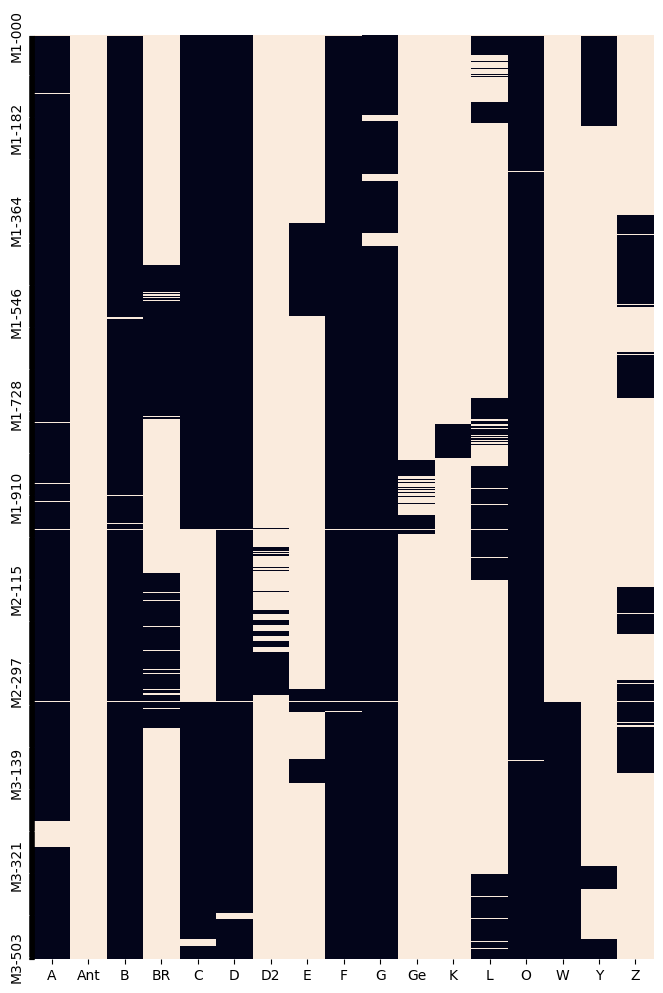

In [376]:
import seaborn as sb
import matplotlib.pyplot as plt
num_labels_to_display = 10  # Change this to the desired number

import seaborn as sb
import matplotlib.pyplot as plt
custom_ytick_labels = [l if i % (len(all_lines) // num_labels_to_display) == 0 else "" for i, l in enumerate(all_lines)]

fig, ax = plt.subplots(figsize=(8, 12))
sb.heatmap(grid, xticklabels=ms_names, yticklabels=custom_ytick_labels, ax=ax, cbar=False)

plt.savefig('heatmap.png')